# Exploratory Data Analysis: European Flight Delay Risk

**Important Context:**

This project intends to build a model and explore the probability of, and factors most affecting flights of Europe's 4 main low cost carriers (EasyJet, Ryanair, Vueling and WIZZ Air) having delays of over 180+ minutes and therefore triggering the EU261 regulation where passenger compesnation is required.

However this EDA is to serve as part of an initial test on a smaller dataset (10 airports over one month - July 2025) before scaling to a full sized dataset (all ~400 airports opearted by these carriers over a full year). As a result as EU261 level delays are exceedinging rare, this small of a dataset will not be effective for analyis of 180+ delays. Therefore the focus is 15+ delays initially.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
df = pd.read_csv("flights_master.csv")

# Ensure datetime columns are parsed
df["flight_date"] = pd.to_datetime(df["flight_date"], errors="coerce")

In [4]:
df.head()

,flight_id,schedule_type,flight_status,airline_iata,airline_name,airline_group,flight_number,flight_iata,origin_iata,destination_iata,...,has_api_arrival_delay,has_arrival_delay,arrival_delay_15_plus,arrival_delay_60_plus,arrival_delay_180_plus,scheduled_departure_time_parsed,flight_date,scheduled_departure_hour,scheduled_departure_day_of_week,scheduled_departure_month
0,FR_1198_FCO_ATH_2025-07-01t05:45:00.000,arrival,landed,FR,ryanair,Ryanair Group,1198,FR1198,FCO,ATH,...,False,True,False,False,False,2025-07-01 05:45:00,2025-07-01,5,Tuesday,7
1,FR_699_VIE_ATH_2025-07-01t06:05:00.000,arrival,landed,FR,ryanair,Ryanair Group,699,FR699,VIE,ATH,...,False,True,False,False,False,2025-07-01 06:05:00,2025-07-01,6,Tuesday,7
2,FR_1237_JTR_ATH_2025-07-01t08:20:00.000,arrival,landed,FR,ryanair,Ryanair Group,1237,FR1237,JTR,ATH,...,False,True,False,False,False,2025-07-01 08:20:00,2025-07-01,8,Tuesday,7
3,W6_2441_BUD_ATH_2025-07-01t06:15:00.000,arrival,landed,W6,wizz air,Wizz Air Group,2441,W62441,BUD,ATH,...,False,True,False,False,False,2025-07-01 06:15:00,2025-07-01,6,Tuesday,7
4,U2_1737_NCE_ATH_2025-07-01t06:00:00.000,arrival,landed,U2,easyjet,easyJet Group,1737,U21737,NCE,ATH,...,True,True,True,False,False,2025-07-01 06:00:00,2025-07-01,6,Tuesday,7


## 1. Dataset Overview

The dataset contains approximately XX,XXX flight records spanning from [date] to [date].

It includes flights from all four major European low-cost carrier groups (Ryanair, easyJet, Wizz Air, and Vueling), with thousands of unique routes across multiple European airports.

A large proportion of flights (~XX%) have usable arrival delay labels, making the dataset suitable for exploratory analysis and predictive modelling.

In [8]:
print("Total rows:", len(df))

print("\nDate range:")
print(df["flight_date"].min(), "→", df["flight_date"].max())

print("\nUnique counts:")
print("Airline groups:", df["airline_group"].nunique())
print("Airline codes:", df["airline_iata"].nunique())
print("Origin airports:", df["origin_iata"].nunique())
print("Destination airports:", df["destination_iata"].nunique())
print("Routes:", df["route"].nunique())

print("\nUsable delay labels:")
print(df["arrival_delay_minutes"].notna().sum())

Total rows: 47559

Date range:
2025-06-30 00:00:00 → 2025-07-31 00:00:00

Unique counts:
Airline groups: 4
Airline codes: 8
Origin airports: 291
Destination airports: 10
Routes: 995

Usable delay labels:
40538


In [6]:
df["airline_group"].value_counts()

,count
airline_group,
Vueling,16331
Ryanair Group,15248
easyJet Group,11068
Wizz Air Group,4912


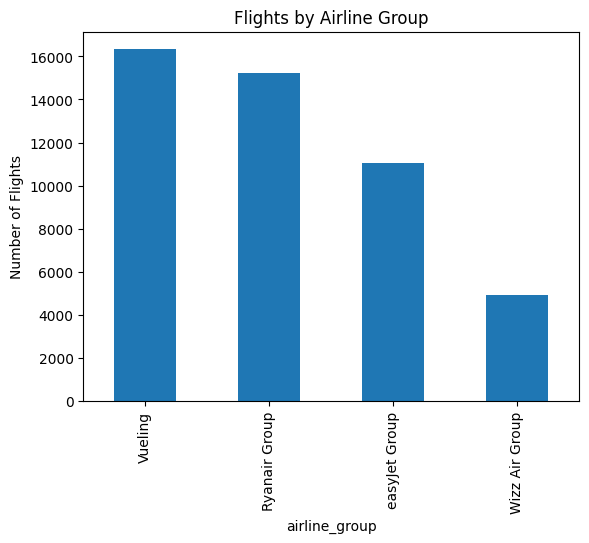

In [7]:
df["airline_group"].value_counts().plot(kind="bar")
plt.title("Flights by Airline Group")
plt.ylabel("Number of Flights")
plt.show()

## 2. Data quality and usable labels

### Missingness Summary

In [12]:
key_columns = [
    "scheduled_departure_time",
    "scheduled_arrival_time",
    "estimated_arrival_time",
    "actual_arrival_time",
    "api_arrival_delay_minutes",
    "arrival_delay_minutes",
]

missing_summary = []

for column in key_columns:
    missing_count = df[column].isna().sum()
    missing_percent = missing_count / len(df) * 100

    missing_summary.append({
        "column": column,
        "missing_count": missing_count,
        "missing_percent": missing_percent,
    })

missing_summary_df = pd.DataFrame(missing_summary)
missing_summary_df.sort_values("missing_percent", ascending=False)

,column,missing_count,missing_percent
4,api_arrival_delay_minutes,25236,53.062512
3,actual_arrival_time,7021,14.762716
5,arrival_delay_minutes,7021,14.762716
2,estimated_arrival_time,1975,4.152737
1,scheduled_arrival_time,0,0.000000
0,scheduled_departure_time,0,0.000000


### Label Availability

In [13]:
label_quality = pd.DataFrame({
    "metric": [
        "Rows with actual arrival time",
        "Rows with calculated arrival delay",
        "Rows with API-provided arrival delay",
        "Duplicate flight IDs",
    ],
    "count": [
        df["actual_arrival_time"].notna().sum(),
        df["arrival_delay_minutes"].notna().sum(),
        df["api_arrival_delay_minutes"].notna().sum(),
        df["flight_id"].duplicated().sum(),
    ],
})

label_quality["percent"] = label_quality["count"] / len(df) * 100
label_quality

,metric,count,percent
0,Rows with actual arrival time,40538,85.237284
1,Rows with calculated arrival delay,40538,85.237284
2,Rows with API-provided arrival delay,22323,46.937488
3,Duplicate flight IDs,0,0.000000


### Status Distribution

In [14]:
status_counts = (
    df["flight_status"]
    .value_counts(dropna=False)
    .rename_axis("flight_status")
    .reset_index(name="flights")
)

status_counts

,flight_status,flights
0,landed,45518
1,unknown,1280
2,cancelled,704
3,diverted,57


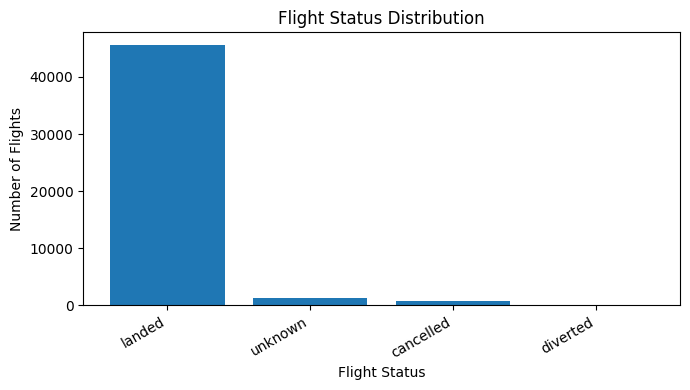

In [15]:
plt.figure(figsize=(7, 4))
plt.bar(status_counts["flight_status"].astype(str), status_counts["flights"])
plt.title("Flight Status Distribution")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### API provided delay vs Caclcualted delay
This was important as although Aviation Edge's documentation mentioend the inclusion of an arrival delay feature, the pulled dataset showed (as seen in label availability above) over 50% of recroded flights had no recorded value for this field, despite their being over 85% of flights with a recorded actual arrival time and scheduled arrival time. Therefore the arrival delay was calculated after using these values rather than using the less reliable field from Aviation Edge.

As a result with the calcuated arrival delay we can have an delay value for about 85% flights rather than just ~47. Below shows that the calculated delay always matched the provided delay (within 5 minutes) and is therefore useable.

In [18]:
delay_diff = df["arrival_delay_difference_api_vs_calculated"].dropna()

delay_diff.describe()

,arrival_delay_difference_api_vs_calculated
count,17295.000000
mean,0.504365
std,0.499995
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


Calculated arrival delay matched that provided by Aviation Edge when available

In [17]:
large_diff_count = (delay_diff.abs() > 5).sum()
large_diff_percent = large_diff_count / len(delay_diff) * 100

print(f"Rows where API delay differs from calculated delay by more than 5 minutes: {large_diff_count}")
print(f"Percentage: {large_diff_percent:.2f}%")

Rows where API delay differs from calculated delay by more than 5 minutes: 0
Percentage: 0.00%


## 3. Delay distribution
Arrival delay is calculated as actual arrival time minus scheduled arrival time. Negative values indicate flights arriving earlier than scheduled, which is common because airline schedules often include buffer time.

In [19]:
delay_df = df[df["arrival_delay_minutes"].notna()].copy()

delay_df["arrival_delay_minutes"].describe()

,arrival_delay_minutes
count,40538.000000
mean,-0.040185
std,19.965550
min,-224.000000
25%,-15.000000
50%,-4.000000
75%,12.000000
max,59.000000


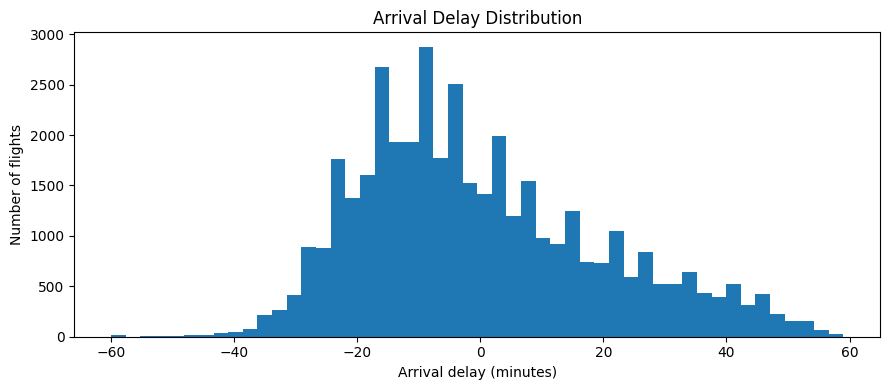

In [20]:
plt.figure(figsize=(9, 4))
plt.hist(delay_df["arrival_delay_minutes"].clip(lower=-60, upper=120), bins=50)
plt.title("Arrival Delay Distribution")
plt.xlabel("Arrival delay (minutes)")
plt.ylabel("Number of flights")
plt.tight_layout()
plt.show()

### Early / on-time / delayed Flights

In [21]:
delay_categories = pd.DataFrame({
    "category": [
        "Early (< -5 min)",
        "On-time (-5 to <15 min)",
        "Delayed 15+ min",
    ],
    "flights": [
        (delay_df["arrival_delay_minutes"] < -5).sum(),
        ((delay_df["arrival_delay_minutes"] >= -5) & (delay_df["arrival_delay_minutes"] < 15)).sum(),
        (delay_df["arrival_delay_minutes"] >= 15).sum(),
    ],
})

delay_categories["percent"] = delay_categories["flights"] / len(delay_df) * 100

delay_categories

,category,flights,percent
0,Early (< -5 min),18841,46.477379
1,On-time (-5 to <15 min),12521,30.887069
2,Delayed 15+ min,9176,22.635552


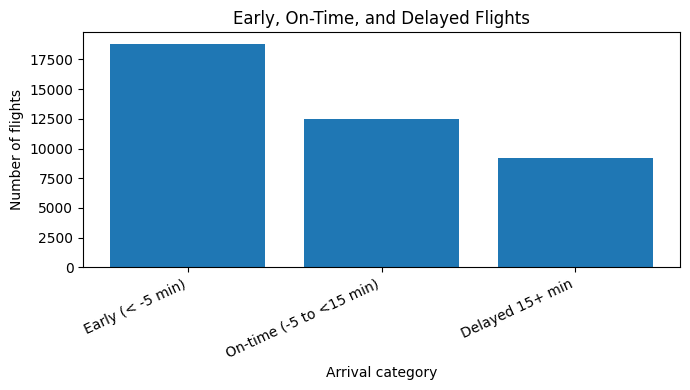

In [22]:
plt.figure(figsize=(7, 4))
plt.bar(delay_categories["category"], delay_categories["flights"])
plt.title("Early, On-Time, and Delayed Flights")
plt.xlabel("Arrival category")
plt.ylabel("Number of flights")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Most flights arrive early or close to schedule, while 15+ minute delays make up a smaller portion of the dataset. The distribution is skewed: many flights have small negative delays due to schedule padding, while positive delays form a smaller right tail. This suggests that delay prediction should be treated as an imbalanced classification problem rather than a balanced prediction task.

## 4. Target balance and class imbalance

The project initially considered severe delay thresholds such as 60+ and 180+ minutes. However, these outcomes are rare in the current smaller scale test dataset and will instead be explored once a larger dataset is collected. This section compares candidate target variables and selects the most suitable target for the first modelling stage.

In [23]:
target_columns = [
    "arrival_delay_15_plus",
    "arrival_delay_60_plus",
    "arrival_delay_180_plus",
]

target_summary = []

for column in target_columns:
    valid_count = df[column].notna().sum()
    positive_count = df[column].sum()
    negative_count = valid_count - positive_count
    positive_rate = positive_count / valid_count * 100 if valid_count > 0 else 0

    target_summary.append({
        "target": column,
        "valid_labels": valid_count,
        "positive_count": positive_count,
        "negative_count": negative_count,
        "positive_rate_percent": positive_rate,
    })

target_summary_df = pd.DataFrame(target_summary)
target_summary_df

,target,valid_labels,positive_count,negative_count,positive_rate_percent
0,arrival_delay_15_plus,40538,9176,31362,22.635552
1,arrival_delay_60_plus,40538,0,40538,0.000000
2,arrival_delay_180_plus,40538,0,40538,0.000000


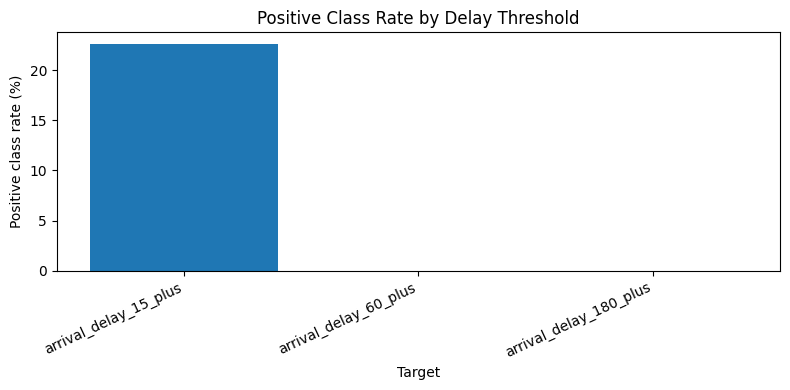

In [24]:
plt.figure(figsize=(8, 4))
plt.bar(target_summary_df["target"], target_summary_df["positive_rate_percent"])
plt.title("Positive Class Rate by Delay Threshold")
plt.xlabel("Target")
plt.ylabel("Positive class rate (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [25]:
MODEL_TARGET = "arrival_delay_15_plus"

model_df = df[df[MODEL_TARGET].notna()].copy()

print("Chosen target:", MODEL_TARGET)
print("Rows usable for modelling:", len(model_df))
print("Positive examples:", model_df[MODEL_TARGET].sum())
print("Positive rate:", f"{model_df[MODEL_TARGET].mean() * 100:.2f}%")

Chosen target: arrival_delay_15_plus
Rows usable for modelling: 40538
Positive examples: 9176
Positive rate: 22.64%


The 15+ minute arrival delay threshold has enough positive examples for an initial classification model. In contrast, 60+ and 180+ minute delays are absent or too rare in the current smaller dataset. Therefore, the first model uses `arrival_delay_15_plus` as the target.

The 60+ and 180+ thresholds remain important for future work, especially for EU261-style compensation analysis, but they require a larger dataset with more rare severe-delay events.

## 5. Delay patterns by airline

This section compares 15+ minute arrival delay rates across airline groups. The goal is to check whether different carrier groups show different delay-risk patterns.

In [26]:
airline_summary = (
    model_df
    .groupby("airline_group")
    .agg(
        flights=("flight_id", "count"),
        delayed_15_plus=("arrival_delay_15_plus", "sum"),
        delay_rate_15_plus=("arrival_delay_15_plus", "mean"),
        mean_arrival_delay=("arrival_delay_minutes", "mean"),
        median_arrival_delay=("arrival_delay_minutes", "median"),
    )
    .sort_values("delay_rate_15_plus", ascending=False)
)

airline_summary["delay_rate_15_plus_percent"] = airline_summary["delay_rate_15_plus"] * 100

airline_summary

,flights,delayed_15_plus,delay_rate_15_plus,mean_arrival_delay,median_arrival_delay,delay_rate_15_plus_percent
airline_group,,,,,,
easyJet Group,8914,2661,0.298519,3.995513,1.0,29.851918
Ryanair Group,12822,3364,0.262362,1.881844,-2.0,26.236157
Wizz Air Group,4262,816,0.191459,-1.802675,-5.0,19.145941
Vueling,14540,2335,0.160591,-3.692641,-8.0,16.059147


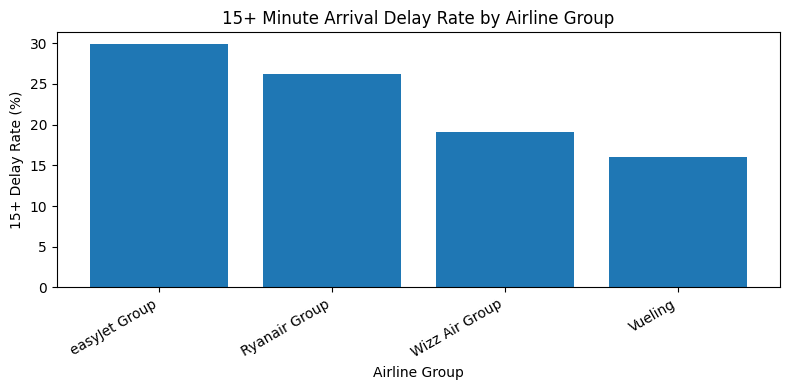

In [27]:
plt.figure(figsize=(8, 4))
plt.bar(
    airline_summary.index,
    airline_summary["delay_rate_15_plus_percent"],
)
plt.title("15+ Minute Arrival Delay Rate by Airline Group")
plt.xlabel("Airline Group")
plt.ylabel("15+ Delay Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

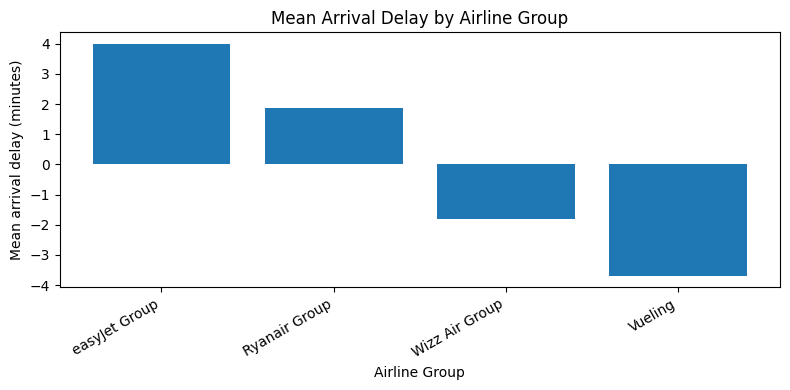

In [28]:
plt.figure(figsize=(8, 4))
plt.bar(
    airline_summary.index,
    airline_summary["mean_arrival_delay"],
)
plt.title("Mean Arrival Delay by Airline Group")
plt.xlabel("Airline Group")
plt.ylabel("Mean arrival delay (minutes)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In this sample, easyJet Group has the highest 15+ minute delay rate, followed by Ryanair Group, Wizz Air Group, and Vueling. This suggests airline group may be a useful model feature, although the result is partly affected by the airports and routes each airline operates in the sampled data.

In [29]:
airline_code_summary = (
    model_df
    .groupby(["airline_group", "airline_iata"])
    .agg(
        flights=("flight_id", "count"),
        delay_rate_15_plus=("arrival_delay_15_plus", "mean"),
        mean_arrival_delay=("arrival_delay_minutes", "mean"),
    )
    .sort_values("delay_rate_15_plus", ascending=False)
)

airline_code_summary["delay_rate_15_plus_percent"] = airline_code_summary["delay_rate_15_plus"] * 100

airline_code_summary

flights delay_rate_15_plus  mean_arrival_delay  \
airline_group  airline_iata                                                   
easyJet Group  U2               8914           0.298519            3.995513   
Ryanair Group  RR                229           0.292576            3.598253   
               FR              12593           0.261812            1.850631   
Wizz Air Group W6               4262           0.191459           -1.802675   
Vueling        VY              14540           0.160591           -3.692641   

                            delay_rate_15_plus_percent  
airline_group  airline_iata                             
easyJet Group  U2                            29.851918  
Ryanair Group  RR                            29.257642  
               FR                            26.181212  
Wizz Air Group W6                            19.145941  
Vueling        VY                            16.059147

The 15+ minute delay rate varies between airline groups, suggesting that carrier identity is likely to be a useful modelling feature. However, these differences should be interpreted carefully because airline performance is also affected by the airports and routes each carrier operates in this sample.

## 6. Delay patterns by time and route

This section checks whether delay risk varies by scheduled departure hour and by route. These are useful candidate features for the predictive model because they are known before the flight departs.

In [30]:
hour_summary = (
    model_df
    .groupby("scheduled_departure_hour")
    .agg(
        flights=("flight_id", "count"),
        delay_rate_15_plus=("arrival_delay_15_plus", "mean"),
        mean_arrival_delay=("arrival_delay_minutes", "mean"),
    )
)

hour_summary["delay_rate_15_plus_percent"] = hour_summary["delay_rate_15_plus"] * 100

hour_summary

,flights,delay_rate_15_plus,mean_arrival_delay,delay_rate_15_plus_percent
scheduled_departure_hour,,,,
0,170,0.2,-5.100000,20.0
1,67,0.19403,-10.074627,19.402985
2,20,0.05,-19.500000,5.0
3,33,0.151515,-10.484848,15.151515
4,72,0.222222,-2.972222,22.222222
5,685,0.042336,-13.157664,4.233577
6,3026,0.065763,-10.529742,6.576338
7,2394,0.078112,-8.266917,7.811195
8,1781,0.110612,-6.539585,11.061202


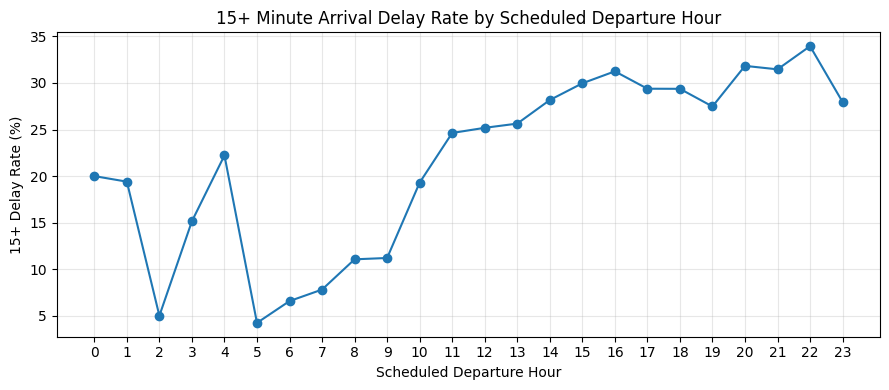

In [31]:
plt.figure(figsize=(9, 4))
plt.plot(
    hour_summary.index,
    hour_summary["delay_rate_15_plus_percent"],
    marker="o",
)
plt.title("15+ Minute Arrival Delay Rate by Scheduled Departure Hour")
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("15+ Delay Rate (%)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Delay by routes

In [32]:
MIN_ROUTE_FLIGHTS = 50

route_summary = (
    model_df
    .groupby("route")
    .agg(
        flights=("flight_id", "count"),
        delayed_15_plus=("arrival_delay_15_plus", "sum"),
        delay_rate_15_plus=("arrival_delay_15_plus", "mean"),
        mean_arrival_delay=("arrival_delay_minutes", "mean"),
    )
)

route_summary["delay_rate_15_plus_percent"] = route_summary["delay_rate_15_plus"] * 100

high_volume_routes = route_summary[route_summary["flights"] >= MIN_ROUTE_FLIGHTS]

top_delayed_routes = high_volume_routes.sort_values(
    "delay_rate_15_plus",
    ascending=False,
).head(10)

top_delayed_routes

,flights,delayed_15_plus,delay_rate_15_plus,mean_arrival_delay,delay_rate_15_plus_percent
route,,,,,
NCE_LGW,83,55,0.662651,22.289157,66.26506
CTA_LGW,50,30,0.6,19.500000,60.0
RHO_LGW,70,38,0.542857,14.785714,54.285714
TIA_STN,66,35,0.530303,16.166667,53.030303
ATH_LGW,93,49,0.526882,15.677419,52.688172
AYT_LGW,63,32,0.507937,13.587302,50.793651
BCN_STN,91,45,0.494505,12.692308,49.450549
MLA_LGW,50,24,0.48,10.660000,48.0
BGY_STN,79,37,0.468354,12.392405,46.835443


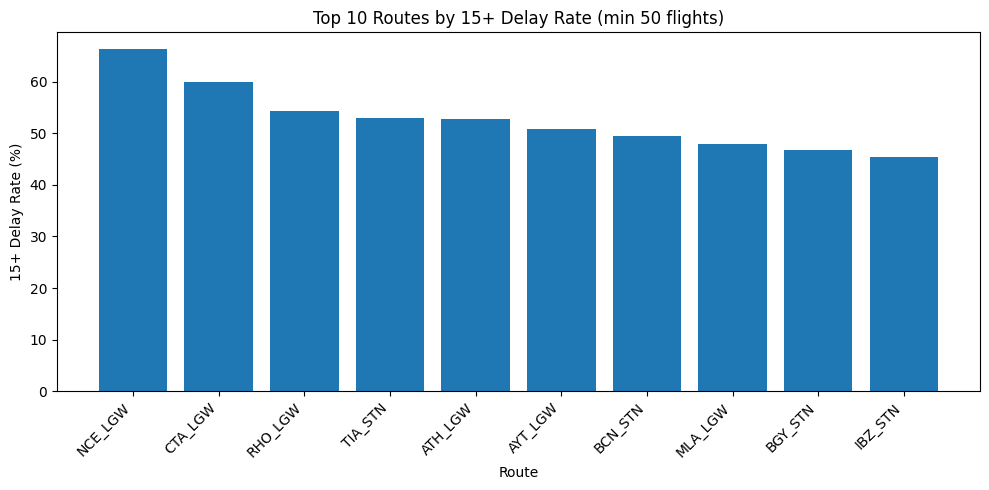

In [33]:
plt.figure(figsize=(10, 5))
plt.bar(
    top_delayed_routes.index,
    top_delayed_routes["delay_rate_15_plus_percent"],
)
plt.title(f"Top 10 Routes by 15+ Delay Rate (min {MIN_ROUTE_FLIGHTS} flights)")
plt.xlabel("Route")
plt.ylabel("15+ Delay Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Busiest Routes and their delays

In [34]:
busiest_routes = route_summary.sort_values("flights", ascending=False).head(10)
busiest_routes

,flights,delayed_15_plus,delay_rate_15_plus,mean_arrival_delay,delay_rate_15_plus_percent
route,,,,,
PMI_BCN,449,97,0.216036,-0.173719,21.603563
IBZ_BCN,414,92,0.222222,1.700483,22.222222
MAH_BCN,358,59,0.164804,-2.365922,16.480447
PMI_MAD,330,36,0.109091,-6.254545,10.909091
BCN_LGW,315,68,0.215873,-0.117460,21.587302
LGW_BCN,307,75,0.2443,1.345277,24.429967
BCN_FCO,286,52,0.181818,-3.122378,18.181818
BCN_MAD,283,32,0.113074,-5.674912,11.30742
MAD_FCO,281,62,0.220641,0.740214,22.064057


The highest-delay routes are not necessarily the busiest routes. For example, routes such as NCE_LGW, CTA_LGW, RHO_LGW, TIA_STN, and ATH_LGW show high 15+ minute delay rates despite having lower volumes than the busiest routes.

This suggests route is likely to be a useful feature, but route-level results should be filtered by minimum sample size to avoid overinterpreting small routes.

Delay rates vary across scheduled departure hours and routes, suggesting that both time-of-day and route are useful candidate features for modelling. Route-level delay rates should be interpreted with care because some routes have much smaller sample sizes, so a minimum flight-count threshold was used before comparing routes.

### Delay by destination airport

In [35]:
MIN_AIRPORT_FLIGHTS = 100

destination_summary = (
    model_df
    .groupby("destination_iata")
    .agg(
        flights=("flight_id", "count"),
        delayed_15_plus=("arrival_delay_15_plus", "sum"),
        delay_rate_15_plus=("arrival_delay_15_plus", "mean"),
        mean_arrival_delay=("arrival_delay_minutes", "mean"),
    )
)

destination_summary["delay_rate_15_plus_percent"] = (
    destination_summary["delay_rate_15_plus"] * 100
)

high_volume_destinations = destination_summary[
    destination_summary["flights"] >= MIN_AIRPORT_FLIGHTS
]

top_delayed_destinations = high_volume_destinations.sort_values(
    "delay_rate_15_plus",
    ascending=False,
).head(10)

top_delayed_destinations

,flights,delayed_15_plus,delay_rate_15_plus,mean_arrival_delay,delay_rate_15_plus_percent
destination_iata,,,,,
NCE,1439,526,0.365532,8.558026,36.553162
STN,5176,1491,0.28806,3.719281,28.806028
LGW,6497,1857,0.285824,3.168847,28.582423
ATH,1142,302,0.264448,3.700525,26.444834
LIS,2076,513,0.24711,1.773121,24.710983
BCN,9025,1929,0.21374,-0.349806,21.373961
BUD,2534,532,0.209945,-0.135754,20.994475
FCO,4083,810,0.198384,-3.095273,19.838354
ZRH,434,84,0.193548,-0.608295,19.354839


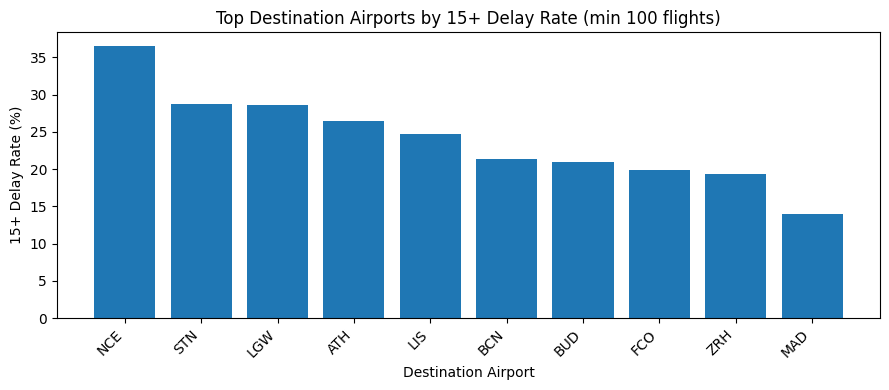

In [36]:
plt.figure(figsize=(9, 4))
plt.bar(
    top_delayed_destinations.index,
    top_delayed_destinations["delay_rate_15_plus_percent"],
)
plt.title(f"Top Destination Airports by 15+ Delay Rate (min {MIN_AIRPORT_FLIGHTS} flights)")
plt.xlabel("Destination Airport")
plt.ylabel("15+ Delay Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Destination airports show clear differences in delay risk. In this sample, NCE has the highest 15+ minute delay rate among high-volume destination airports, followed by STN, LGW, ATH, and LIS. This suggests arrival-side airport effects may be important, potentially reflecting congestion, weather, air traffic control restrictions, or airport operating conditions.

### Delay by departure airport

In [37]:
origin_summary = (
    model_df
    .groupby("origin_iata")
    .agg(
        flights=("flight_id", "count"),
        delayed_15_plus=("arrival_delay_15_plus", "sum"),
        delay_rate_15_plus=("arrival_delay_15_plus", "mean"),
        mean_arrival_delay=("arrival_delay_minutes", "mean"),
    )
)

origin_summary["delay_rate_15_plus_percent"] = (
    origin_summary["delay_rate_15_plus"] * 100
)

high_volume_origins = origin_summary[
    origin_summary["flights"] >= MIN_AIRPORT_FLIGHTS
]

top_delayed_origins = high_volume_origins.sort_values(
    "delay_rate_15_plus",
    ascending=False,
).head(10)

top_delayed_origins

,flights,delayed_15_plus,delay_rate_15_plus,mean_arrival_delay,delay_rate_15_plus_percent
origin_iata,,,,,
OLB,106,57,0.537736,16.141509,53.773585
NCE,314,144,0.458599,13.156051,45.859873
RHO,127,51,0.401575,9.440945,40.15748
BHX,121,45,0.371901,8.867769,37.190083
BGY,283,103,0.363958,8.134276,36.39576
PSA,171,59,0.345029,8.409357,34.502924
ATH,381,131,0.343832,6.601050,34.383202
HER,114,38,0.333333,5.377193,33.333333
BVA,169,55,0.325444,6.230769,32.544379


Origin airports also show substantial variation in 15+ minute delay rates. Some high-delay origin airports, such as OLB, NCE, RHO, BHX, and BGY, may reflect route network effects, seasonal leisure travel, or disruption at the departure airport.

Because origin and destination airports capture different operational pressures, both should be considered as candidate model features.

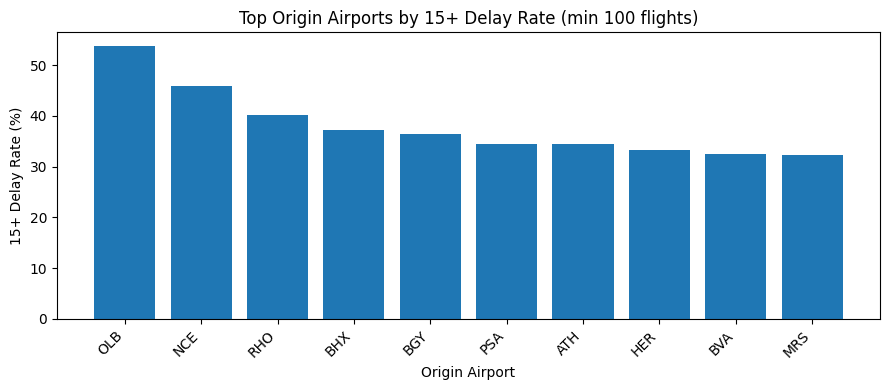

In [38]:
plt.figure(figsize=(9, 4))
plt.bar(
    top_delayed_origins.index,
    top_delayed_origins["delay_rate_15_plus_percent"],
)
plt.title(f"Top Origin Airports by 15+ Delay Rate (min {MIN_AIRPORT_FLIGHTS} flights)")
plt.xlabel("Origin Airport")
plt.ylabel("15+ Delay Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Delay risk varies noticeably by scheduled departure hour, destination airport, origin airport, and route. This supports using time-of-day, route, origin airport, and destination airport as candidate model features.

Destination-airport patterns may reflect arrival-side congestion, weather, air traffic control restrictions, and airport operations. Origin-airport patterns may reflect departure-side disruption, airline base operations, and route network effects. Route-level delay rates combine both airport effects and airline operating patterns, which makes route a potentially strong predictive feature.

Minimum flight-count thresholds were used when ranking airports and routes to reduce the risk of overinterpreting very small samples.

## 7. EDA conclusions

The current dataset contains tens of thousands of European low-cost carrier flight records across Ryanair Group, easyJet Group, Wizz Air Group, and Vueling. Most rows have usable arrival-delay labels after calculating delay directly from scheduled and actual arrival timestamps.

A key data-quality finding is that the API-provided arrival delay field is much sparser than the timestamp fields. Because calculated delay closely matches the API-provided delay when both are available, the timestamp-derived `arrival_delay_minutes` field is used as the main label source.

The delay distribution is imbalanced. Most flights arrive early or close to schedule, while 15+ minute delays form a smaller but still usable positive class. Severe 60+ and 180+ minute delays are absent or too rare in this MVP dataset, so the first modelling target is `arrival_delay_15_plus`.

EDA suggests that airline group, route, origin airport, destination airport, and scheduled departure hour all show meaningful variation in delay risk. These fields are known before departure, making them suitable candidate features for a pre-flight delay-risk model.

The next stage trains baseline classification models to predict whether a flight will arrive 15+ minutes late.